# 1. Inicialização

In [72]:
%pip install xgboost tabpfn scipy matplotlib seaborn -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [73]:
!huggingface-cli login

/usr/bin/bash: linha 1: huggingface-cli: comando não encontrado


In [74]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import pickle
import time
from datetime import datetime

from xgboost import XGBClassifier
from tabpfn import TabPFNClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, matthews_corrcoef
from scipy.stats import wilcoxon

RANDOM_STATE = 42
print("Imports concluídos com sucesso.")

Imports concluídos com sucesso.


In [75]:
## Especificações do Ambiente
import platform, xgboost, tabpfn, sklearn, scipy

print("=== Ambiente de Execução ===")
print(f"Python:       {platform.python_version()}")
print(f"OS:           {platform.system()} {platform.release()}")
print(f"xgboost:      {xgboost.__version__}")
print(f"tabpfn:       {tabpfn.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"scipy:        {scipy.__version__}")
print(f"pandas:       {pd.__version__}")
print(f"numpy:        {np.__version__}")

# Verificar disponibilidade de GPU
try:
    import torch
    device_info = "CUDA disponível" if torch.cuda.is_available() else "CPU apenas"
    print(f"Device:       {device_info}")
except ImportError:
    print("Device:       torch não instalado — usando CPU")

=== Ambiente de Execução ===
Python:       3.14.3
OS:           Linux 6.19.5-gentoo-dist
xgboost:      3.1.3
tabpfn:       6.3.2
scikit-learn: 1.7.2
scipy:        1.17.0
pandas:       2.3.3
numpy:        2.4.1
Device:       CUDA disponível


In [76]:
df = pd.read_csv("https://github.com/Nertonm/tabpfn-xgboost-fairness-comparison/raw/refs/heads/main/data/prefeito_ceara.csv", encoding='latin1', sep=';')

In [77]:
display(df)

,Código município,Cor/raça,Estado civil,Faixa etária,Gênero,Grau de instrução,Município,Nome candidato,Número candidato,Ocupação,Partido,Situação totalização,Votos válidos,Votos nominais,Data de carga
0,14630,Parda,Casado(a),40 a 44 anos,Masculino,Superior completo,MAURITI,JOÃO PAULO FURTADO,13,Prefeito,PT,Eleito,28644,20593,2026-02-28 19:30:47
1,13358,Parda,Divorciado(a),45 a 49 anos,Masculino,Ensino Médio completo,BAIXIO,LUCIO ALVES BARROSO,10,Empresário,REPUBLICANOS,Eleito,4916,2542,2026-02-28 19:30:47
2,13897,Branca,Casado(a),55 a 59 anos,Masculino,Superior completo,FORTALEZA,EVANDRO SA BARRETO LEITAO,13,Deputado,PT,Eleito,1421428,716133,2026-02-28 19:30:47
3,15997,Parda,Divorciado(a),60 a 64 anos,Feminino,Superior completo,PARAIPABA,JOANA D' ARC BATISTA CARVALHO,55,Aposentado (Exceto Servidor Público),PSD,Não Eleito,20496,0,2026-02-28 19:30:47
4,14753,Branca,Casado(a),35 a 39 anos,Masculino,Superior completo,MORADA NOVA,MARCO ANTONIO DE ARAUJO BICA JUNIOR,13,Advogado,PT,Não Eleito,48016,23206,2026-02-28 19:30:47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,15032,Branca,Casado(a),45 a 49 anos,Masculino,Superior completo,PALMÁCIA,LEONARDO ARAÚJO DE SOUZA,40,Advogado,PSB,Não Eleito,8526,4196,2026-02-28 19:30:47
470,13218,Branca,Solteiro(a),30 a 34 anos,Masculino,Superior completo,ARACATI,CAETANO GUEDES NETO,10,Empresário,REPUBLICANOS,Não Eleito,46893,20068,2026-02-28 19:30:47
471,15016,Parda,Casado(a),55 a 59 anos,Masculino,Superior completo,PALHANO,JOÃO BATISTA DE SANTIAGO,55,Outros,PSD,Não Eleito,8803,4080,2026-02-28 19:30:47
472,13005,Branca,Solteiro(a),45 a 49 anos,Masculino,Superior incompleto,JIJOCA DE JERICOACOARA,MARCIO ALDIGUERI ARRUDA,55,Empresário,PSD,Não Eleito,17991,5691,2026-02-28 19:30:47


# 2. Tratamento dos dados

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474 entries, 0 to 473
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Código município      474 non-null    int64 
 1   Cor/raça              474 non-null    object
 2   Estado civil          474 non-null    object
 3   Faixa etária          474 non-null    object
 4   Gênero                474 non-null    object
 5   Grau de instrução     474 non-null    object
 6   Município             474 non-null    object
 7   Nome candidato        474 non-null    object
 8   Número candidato      474 non-null    int64 
 9   Ocupação              474 non-null    object
 10  Partido               474 non-null    object
 11  Situação totalização  474 non-null    object
 12  Votos válidos         474 non-null    int64 
 13  Votos nominais        474 non-null    int64 
 14  Data de carga         474 non-null    object
dtypes: int64(4), object(11)
memory usage: 55

In [79]:
df = df[df["Situação totalização"] != "Segundo turno"]

## 2.1. Filtragem e Remoção de Data Leakage

In [80]:
# Removemos colunas irrelevantes e features pós-eleição (data leakage)
# "Votos válidos" e "Votos nominais" só existem APÓS o evento — removê-las antes do split é obrigatório
df = df.drop(["Nome candidato", "Data de carga", "Município",
              "Votos válidos", "Votos nominais"], axis=1)
print("Colunas após remoção de features com data leakage:")
print(df.columns.tolist())

Colunas após remoção de features com data leakage:
['Código município', 'Cor/raça', 'Estado civil', 'Faixa etária', 'Gênero', 'Grau de instrução', 'Número candidato', 'Ocupação', 'Partido', 'Situação totalização']


## 2.2. Análise Exploratória de Viés nos Dados Brutos

Quantificamos o desbalanceamento histórico nos dados brutos para estabelecer o **viés de referência** que os modelos podem mitigar ou amplificar.

In [81]:
# Criar flag temporária de eleito para EDA
eleito_flag = (df["Situação totalização"] == "Eleito").astype(int)

# --- Distribuição por Gênero ---
genero_dist = df.groupby("Gênero").apply(lambda g: pd.Series({
    "Total": len(g),
    "Eleitos": eleito_flag[g.index].sum(),
    "Taxa de Vitória (%)": round(eleito_flag[g.index].mean() * 100, 2)
})).reset_index()
print("=== Distribuição de Eleitos por Gênero ===")
display(genero_dist)

# --- Distribuição por Raça/Cor ---
raca_dist = df.groupby("Cor/raça").apply(lambda g: pd.Series({
    "Total": len(g),
    "Eleitos": eleito_flag[g.index].sum(),
    "Taxa de Vitória (%)": round(eleito_flag[g.index].mean() * 100, 2)
})).reset_index()
print("\n=== Distribuição de Eleitos por Raça/Cor ===")
display(raca_dist)

=== Distribuição de Eleitos por Gênero ===


,Gênero,Total,Eleitos,Taxa de Vitória (%)
0,Feminino,95.0,38.0,40.00
1,Masculino,375.0,146.0,38.93



=== Distribuição de Eleitos por Raça/Cor ===


,Cor/raça,Total,Eleitos,Taxa de Vitória (%)
0,Amarela,1.0,0.0,0.00
1,Branca,252.0,100.0,39.68
2,Não Informado,3.0,1.0,33.33
3,Parda,200.0,82.0,41.00
4,Preta,14.0,1.0,7.14


In [82]:
# --- Tabela Cruzada: Gênero × Raça × Eleito (Interseccionalidade) ---
df_eda = df[["Gênero", "Cor/raça"]].copy()
df_eda["Eleito"] = eleito_flag
cross = df_eda.groupby(["Gênero", "Cor/raça"])["Eleito"].agg(["count", "sum", "mean"])
cross.columns = ["Total", "Eleitos", "Taxa de Vitória"]
cross["Taxa de Vitória (%)"] = (cross["Taxa de Vitória"] * 100).round(2)
cross = cross.drop("Taxa de Vitória", axis=1)
print("=== Tabela de Interseccionalidade: Gênero × Raça × Eleito ===")
display(cross)

=== Tabela de Interseccionalidade: Gênero × Raça × Eleito ===


Total  Eleitos  Taxa de Vitória (%)
Gênero    Cor/raça                                          
Feminino  Branca            59       25                42.37
          Parda             32       13                40.62
          Preta              4        0                 0.00
Masculino Amarela            1        0                 0.00
          Branca           193       75                38.86
          Não Informado      3        1                33.33
          Parda            168       69                41.07
          Preta             10        1                10.00

In [83]:
# Encoding com LabelEncoder (consistente com pipeline de produção do projeto)
cat_cols = ["Cor/raça", "Estado civil", "Faixa etária", "Gênero",
            "Grau de instrução", "Ocupação", "Partido"]

mapper = {
    "Cor/raça":          "Código cor",
    "Estado civil":      "Código civil",
    "Faixa etária":      "Código etária",
    "Gênero":            "Código gênero",
    "Grau de instrução": "Código instrução",
    "Ocupação":          "Código ocupação",
    "Partido":           "Código partido",
}

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[mapper[col]] = le.fit_transform(df[col])
    encoders[col] = le

df["Eleito"] = (df["Situação totalização"] == "Eleito").astype(int)

# --- Mapeamentos explícitos para uso nas métricas de fairness ---
gender_map = dict(zip(encoders["Gênero"].classes_,
                      encoders["Gênero"].transform(encoders["Gênero"].classes_)))
race_map   = dict(zip(encoders["Cor/raça"].classes_,
                      encoders["Cor/raça"].transform(encoders["Cor/raça"].classes_)))

print("Mapeamento Gênero:", gender_map)
print("Mapeamento Raça:  ", race_map)
print("\nEncoding concluído. Mapeamentos salvos em `encoders`, `gender_map` e `race_map`.")

Mapeamento Gênero: {'Feminino': np.int64(0), 'Masculino': np.int64(1)}
Mapeamento Raça:   {'Amarela': np.int64(0), 'Branca': np.int64(1), 'Não Informado': np.int64(2), 'Parda': np.int64(3), 'Preta': np.int64(4)}

Encoding concluído. Mapeamentos salvos em `encoders`, `gender_map` e `race_map`.


In [84]:
display(df)

,Código município,Cor/raça,Estado civil,Faixa etária,Gênero,Grau de instrução,Número candidato,Ocupação,Partido,Situação totalização,Código cor,Código civil,Código etária,Código gênero,Código instrução,Código ocupação,Código partido,Eleito
0,14630,Parda,Casado(a),40 a 44 anos,Masculino,Superior completo,13,Prefeito,PT,Eleito,3,0,4,1,5,33,20,1
1,13358,Parda,Divorciado(a),45 a 49 anos,Masculino,Ensino Médio completo,10,Empresário,REPUBLICANOS,Eleito,3,1,5,1,2,14,22,1
2,13897,Branca,Casado(a),55 a 59 anos,Masculino,Superior completo,13,Deputado,PT,Eleito,1,0,7,1,5,12,20,1
3,15997,Parda,Divorciado(a),60 a 64 anos,Feminino,Superior completo,55,Aposentado (Exceto Servidor Público),PSD,Não Eleito,3,1,8,0,5,6,16,0
4,14753,Branca,Casado(a),35 a 39 anos,Masculino,Superior completo,13,Advogado,PT,Não Eleito,1,0,3,1,5,1,20,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,15032,Branca,Casado(a),45 a 49 anos,Masculino,Superior completo,40,Advogado,PSB,Não Eleito,1,0,5,1,5,1,15,0
470,13218,Branca,Solteiro(a),30 a 34 anos,Masculino,Superior completo,10,Empresário,REPUBLICANOS,Não Eleito,1,3,2,1,5,14,22,0
471,15016,Parda,Casado(a),55 a 59 anos,Masculino,Superior completo,55,Outros,PSD,Não Eleito,3,0,7,1,5,28,16,0
472,13005,Branca,Solteiro(a),45 a 49 anos,Masculino,Superior incompleto,55,Empresário,PSD,Não Eleito,1,3,5,1,6,14,16,0


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 470 entries, 0 to 473
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Código município      470 non-null    int64 
 1   Cor/raça              470 non-null    object
 2   Estado civil          470 non-null    object
 3   Faixa etária          470 non-null    object
 4   Gênero                470 non-null    object
 5   Grau de instrução     470 non-null    object
 6   Número candidato      470 non-null    int64 
 7   Ocupação              470 non-null    object
 8   Partido               470 non-null    object
 9   Situação totalização  470 non-null    object
 10  Código cor            470 non-null    int64 
 11  Código civil          470 non-null    int64 
 12  Código etária         470 non-null    int64 
 13  Código gênero         470 non-null    int64 
 14  Código instrução      470 non-null    int64 
 15  Código ocupação       470 non-null    int64 


In [86]:
# Remove colunas categóricas originais (já codificadas) e a target textual
df = df.drop(["Situação totalização", "Cor/raça", "Estado civil",
              "Faixa etária", "Gênero", "Grau de instrução",
              "Ocupação", "Partido"], axis=1)
print(f"Shape final: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")

Shape final: (470, 10)
Colunas: ['Código município', 'Número candidato', 'Código cor', 'Código civil', 'Código etária', 'Código gênero', 'Código instrução', 'Código ocupação', 'Código partido', 'Eleito']


In [87]:
display(df)

,Código município,Número candidato,Código cor,Código civil,Código etária,Código gênero,Código instrução,Código ocupação,Código partido,Eleito
0,14630,13,3,0,4,1,5,33,20,1
1,13358,10,3,1,5,1,2,14,22,1
2,13897,13,1,0,7,1,5,12,20,1
3,15997,55,3,1,8,0,5,6,16,0
4,14753,13,1,0,3,1,5,1,20,0
...,...,...,...,...,...,...,...,...,...,...
469,15032,40,1,0,5,1,5,1,15,0
470,13218,10,1,3,2,1,5,14,22,0
471,15016,55,3,0,7,1,5,28,16,0
472,13005,55,1,3,5,1,6,14,16,0


# 3. Métricas de Fairness

Implementação de duas métricas de equidade algorítmica para validar a hipótese central do projeto:
- **DIR (Disparate Impact Ratio)**: razão de predições positivas entre grupos. Ideal = 1.0; < 0.8 = viés estrutural
- **EOD (Equal Opportunity Difference)**: diferença de TPR entre grupos. Ideal = 0.0

In [88]:
def disparate_impact_ratio(y_true, y_pred, sensitive_attr, privileged_value,
                           unprivileged_value=None):
    """
    DIR = P(ŷ=1 | não-privilegiado) / P(ŷ=1 | privilegiado)
    Ideal = 1.0 | < 0.8 indica viés estrutural (EEOC 4/5 rule)

    Se unprivileged_value=None, considera todos os não-privilegiados como grupo único.
    Se unprivileged_value é fornecido, compara especificamente esse par.
    """
    y_pred = np.array(y_pred)
    sensitive_attr = np.array(sensitive_attr)
    mask_priv = sensitive_attr == privileged_value
    mask_unpriv = (sensitive_attr == unprivileged_value) if unprivileged_value is not None \
                  else ~mask_priv
    if mask_priv.sum() == 0 or mask_unpriv.sum() == 0:
        return np.nan
    rate_priv   = y_pred[mask_priv].mean()
    rate_unpriv = y_pred[mask_unpriv].mean()
    return rate_unpriv / rate_priv if rate_priv > 0 else np.nan


def equal_opportunity_difference(y_true, y_pred, sensitive_attr, privileged_value,
                                 unprivileged_value=None):
    """
    EOD = TPR(privilegiado) - TPR(não-privilegiado)
    Ideal = 0.0

    Se unprivileged_value=None, considera todos os não-privilegiados como grupo único.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    sensitive_attr = np.array(sensitive_attr)
    mask_priv_pos = (sensitive_attr == privileged_value) & (y_true == 1)
    mask_unpriv_pos = ((sensitive_attr == unprivileged_value) if unprivileged_value is not None
                       else (sensitive_attr != privileged_value)) & (y_true == 1)
    if mask_priv_pos.sum() == 0 or mask_unpriv_pos.sum() == 0:
        return np.nan
    tpr_priv   = y_pred[mask_priv_pos].mean()
    tpr_unpriv = y_pred[mask_unpriv_pos].mean()
    return tpr_priv - tpr_unpriv


print("Métricas de fairness definidas: DIR e EOD (com suporte a pares específicos)")

Métricas de fairness definidas: DIR e EOD (com suporte a pares específicos)


# 4. Treinamento com Validação Cruzada Estratificada

`StratifiedKFold(n_splits=5)` garante representação proporcional da classe minoritária em cada fold, eliminando a dependência amostral de um único split 80/20.

Três modelos são avaliados em paralelo:
- **XGBoost** — baseline
- **TabPFN** — modelo transformer bayesiano
- **XGBoost Blind** — treina *sem* `Código gênero` e `Código cor` para quantificar dependência em atributos sensíveis

In [89]:
def record(results, model_key, y_test, y_pred, sens_gender, sens_race,
           priv_gender, priv_race, race_minority_pairs, elapsed):
    """Registra todas as métricas de um modelo para um fold."""
    r = results[model_key]
    r["mcc"].append(matthews_corrcoef(y_test, y_pred))
    r["dir_gender"].append(disparate_impact_ratio(y_test, y_pred, sens_gender, priv_gender))
    r["eod_gender"].append(equal_opportunity_difference(y_test, y_pred, sens_gender, priv_gender))
    r["dir_race"].append(disparate_impact_ratio(y_test, y_pred, sens_race, priv_race))
    r["eod_race"].append(equal_opportunity_difference(y_test, y_pred, sens_race, priv_race))
    r["time"].append(elapsed)
    for cat, code in race_minority_pairs.items():
        key_d = f"dir_{cat.lower().replace(' ', '_')}_vs_branca"
        key_e = f"eod_{cat.lower().replace(' ', '_')}_vs_branca"
        r[key_d].append(disparate_impact_ratio(y_test, y_pred, sens_race, priv_race, code))
        r[key_e].append(equal_opportunity_difference(y_test, y_pred, sens_race, priv_race, code))

print("Função record() definida.")

Função record() definida.


In [90]:
X = df.drop("Eleito", axis=1)
y = df["Eleito"]

# Grupos privilegiados derivados diretamente dos LabelEncoders (sem hardcode)
PRIV_GENDER = gender_map['Masculino']
PRIV_RACE   = race_map['Branca']

# Grupos minoritários de raça para análise de pares específicos
RACE_MINORITY_PAIRS = {
    cat: code for cat, code in race_map.items()
    if cat not in ('Branca', 'Não informado', 'Não Informado')
}

GENDER_COL = "Código gênero"
RACE_COL   = "Código cor"
BLIND_DROP = [GENDER_COL, RACE_COL]

print(f"Grupo privilegiado gênero : Masculino → código {PRIV_GENDER}")
print(f"Grupo privilegiado raça   : Branca    → código {PRIV_RACE}")
print(f"Pares de raça a analisar  : {RACE_MINORITY_PAIRS}")
print(f"Desbalanceamento (neg/pos): {(y==0).sum()} / {(y==1).sum()}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

race_pair_keys     = [f"dir_{c.lower().replace(' ', '_')}_vs_branca" for c in RACE_MINORITY_PAIRS]
race_pair_eod_keys = [f"eod_{c.lower().replace(' ', '_')}_vs_branca" for c in RACE_MINORITY_PAIRS]
base_metrics = ["mcc", "dir_gender", "eod_gender", "dir_race", "eod_race", "time"]

results = {
    m: {k: [] for k in base_metrics + race_pair_keys + race_pair_eod_keys}
    for m in ["xgboost", "tabpfn", "xgb_blind", "dummy"]
}

last_models = {}
# Dados do último fold (reutilizados nas visualizações — sem re-treino)
last_fold_data = {}

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    sens_gender = X_test[GENDER_COL].values
    sens_race   = X_test[RACE_COL].values

    # scale_pos_weight calculado dinamicamente por fold
    spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    print(f"\n--- Fold {fold}/5  (scale_pos_weight={spw:.2f}) ---")

    # --- XGBoost ---
    t0 = time.time()
    xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                         scale_pos_weight=spw, eval_metric='logloss',
                         random_state=RANDOM_STATE)
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    record(results, "xgboost", y_test, y_pred_xgb, sens_gender, sens_race,
           PRIV_GENDER, PRIV_RACE, RACE_MINORITY_PAIRS, time.time() - t0)
    last_models["xgboost"] = xgb
    print(f"  XGBoost   MCC={results['xgboost']['mcc'][-1]:.3f}  DIR_gen={results['xgboost']['dir_gender'][-1]:.3f}")

    # --- TabPFN ---
    t0 = time.time()
    pfn = TabPFNClassifier(device='cpu')
    pfn.fit(X_train, y_train)
    y_pred_pfn = pfn.predict(X_test)
    record(results, "tabpfn", y_test, y_pred_pfn, sens_gender, sens_race,
           PRIV_GENDER, PRIV_RACE, RACE_MINORITY_PAIRS, time.time() - t0)
    last_models["tabpfn"] = pfn
    print(f"  TabPFN    MCC={results['tabpfn']['mcc'][-1]:.3f}  DIR_gen={results['tabpfn']['dir_gender'][-1]:.3f}")

    # --- XGBoost Blind (sem atributos sensíveis) ---
    X_tr_b = X_train.drop(columns=BLIND_DROP)
    X_te_b = X_test.drop(columns=BLIND_DROP)
    t0 = time.time()
    xgb_blind = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                               scale_pos_weight=spw, eval_metric='logloss',
                               random_state=RANDOM_STATE)
    xgb_blind.fit(X_tr_b, y_train)
    y_pred_blind = xgb_blind.predict(X_te_b)
    record(results, "xgb_blind", y_test, y_pred_blind, sens_gender, sens_race,
           PRIV_GENDER, PRIV_RACE, RACE_MINORITY_PAIRS, time.time() - t0)
    last_models["xgb_blind"] = xgb_blind
    print(f"  XGB Blind MCC={results['xgb_blind']['mcc'][-1]:.3f}  DIR_gen={results['xgb_blind']['dir_gender'][-1]:.3f}")

    # --- Baseline: DummyClassifier (stratified) ---
    t0 = time.time()
    dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)
    y_pred_dummy = dummy.predict(X_test)
    record(results, "dummy", y_test, y_pred_dummy, sens_gender, sens_race,
           PRIV_GENDER, PRIV_RACE, RACE_MINORITY_PAIRS, time.time() - t0)
    print(f"  Dummy     MCC={results['dummy']['mcc'][-1]:.3f}")

    # Salva dados do último fold para visualizações (evita re-treino posterior)
    if fold == 5:
        last_fold_data = {
            "X_test":     X_test,
            "y_test":     y_test,
            "sens_gender": sens_gender,
            "y_pred_xgb": y_pred_xgb,
        }

print("\nValidação cruzada concluída.")

Grupo privilegiado gênero : Masculino → código 1
Grupo privilegiado raça   : Branca    → código 1
Pares de raça a analisar  : {'Amarela': np.int64(0), 'Parda': np.int64(3), 'Preta': np.int64(4)}
Desbalanceamento (neg/pos): 286 / 184

--- Fold 1/5  (scale_pos_weight=1.56) ---
  XGBoost   MCC=0.250  DIR_gen=1.184
  TabPFN    MCC=0.481  DIR_gen=1.421
  XGB Blind MCC=0.213  DIR_gen=1.555
  Dummy     MCC=0.028

--- Fold 2/5  (scale_pos_weight=1.56) ---
  XGBoost   MCC=0.351  DIR_gen=0.786
  TabPFN    MCC=0.475  DIR_gen=0.585
  XGB Blind MCC=0.391  DIR_gen=0.841
  Dummy     MCC=0.073

--- Fold 3/5  (scale_pos_weight=1.56) ---
  XGBoost   MCC=0.119  DIR_gen=1.215
  TabPFN    MCC=0.480  DIR_gen=0.623
  XGB Blind MCC=0.250  DIR_gen=1.019
  Dummy     MCC=-0.108

--- Fold 4/5  (scale_pos_weight=1.56) ---
  XGBoost   MCC=0.327  DIR_gen=1.000
  TabPFN    MCC=0.432  DIR_gen=0.854
  XGB Blind MCC=0.283  DIR_gen=1.009
  Dummy     MCC=0.073

--- Fold 5/5  (scale_pos_weight=1.54) ---
  XGBoost   MCC=0.3

# 5. Resultados Comparativos

Métricas agregadas (média ± desvio padrão) sobre os 5 folds. Teste de Wilcoxon signed-rank para significância estatística da diferença de MCC entre XGBoost e TabPFN.

In [91]:
def fmt(values):
    arr = np.array([v for v in values if v is not None and not np.isnan(v)])
    if len(arr) == 0:
        return "     N/A"
    return f"{arr.mean():.3f} ± {arr.std():.3f}"

# --- Tabela Principal ---
print("=" * 76)
print(f"{'Métrica':<30} {'XGBoost':>14} {'TabPFN':>14} {'XGB Blind':>14}")
print("=" * 76)
main_metrics = [
    ("MCC",           "mcc"),
    ("DIR (Gênero)",  "dir_gender"),
    ("EOD (Gênero)",  "eod_gender"),
    ("DIR (Raça — todos)", "dir_race"),
    ("EOD (Raça — todos)", "eod_race"),
]
for label, key in main_metrics:
    print(f"{label:<30} {fmt(results['xgboost'][key]):>14} "
          f"{fmt(results['tabpfn'][key]):>14} {fmt(results['xgb_blind'][key]):>14}")

# Pares específicos de raça
print("-" * 76)
for cat in RACE_MINORITY_PAIRS:
    key_d = f"dir_{cat.lower().replace(' ', '_')}_vs_branca"
    key_e = f"eod_{cat.lower().replace(' ', '_')}_vs_branca"
    label_d = f"DIR ({cat} vs Branca)"
    label_e = f"EOD ({cat} vs Branca)"
    print(f"{label_d:<30} {fmt(results['xgboost'][key_d]):>14} "
          f"{fmt(results['tabpfn'][key_d]):>14} {fmt(results['xgb_blind'][key_d]):>14}")
    print(f"{label_e:<30} {fmt(results['xgboost'][key_e]):>14} "
          f"{fmt(results['tabpfn'][key_e]):>14} {fmt(results['xgb_blind'][key_e]):>14}")

# Baseline dummy
print("-" * 76)
print(f"{'MCC (Dummy Baseline)':<30} {fmt(results['dummy']['mcc']):>14}")
print("=" * 76)

# --- Testes de Wilcoxon com Correção de Bonferroni ---
print("\n=== Testes de Wilcoxon (XGBoost vs TabPFN) com Correção de Bonferroni ===")
test_pairs = [
    ("MCC",           "mcc"),
    ("DIR (Gênero)",  "dir_gender"),
    ("EOD (Gênero)",  "eod_gender"),
    ("DIR (Raça)",    "dir_race"),
    ("EOD (Raça)",    "eod_race"),
]
alpha = 0.05
alpha_bonf = alpha / len(test_pairs)
print(f"α original = {alpha} | α Bonferroni = {alpha_bonf:.4f} ({len(test_pairs)} testes)\n")
print(f"{'Métrica':<22} {'Estatística':>12} {'p-valor':>10} {'Sig. (Bonf.)':>14}")
print("-" * 62)
for label, key in test_pairs:
    v1 = [v for v in results["xgboost"][key] if not np.isnan(v)]
    v2 = [v for v in results["tabpfn"][key] if not np.isnan(v)]
    if len(v1) < 2 or len(v2) < 2 or len(v1) != len(v2):
        print(f"{label:<22} {'N/A':>12} {'N/A':>10} {'N/A':>14}")
        continue
    try:
        st, pv = wilcoxon(v1, v2)
        sig = "✓  p < α_bonf" if pv < alpha_bonf else "✗  p ≥ α_bonf"
        print(f"{label:<22} {st:>12.4f} {pv:>10.4f} {sig:>14}")
    except Exception as e:
        print(f"{label:<22} {'erro':>12} {str(e):>10}")

# --- Análise ΔMCC Blind ---
print(f"\nΔMCC (XGBoost → XGBoost Blind):")
delta = np.mean(results["xgboost"]["mcc"]) - np.mean(results["xgb_blind"]["mcc"])
print(f"  ΔMCC = {delta:+.3f} — {'dependência relevante em atributos sensíveis' if abs(delta) > 0.02 else 'dependência baixa em atributos sensíveis'}")

Métrica                               XGBoost         TabPFN      XGB Blind
MCC                             0.284 ± 0.093  0.452 ± 0.035  0.296 ± 0.064
DIR (Gênero)                    1.085 ± 0.172  0.953 ± 0.341  1.163 ± 0.266
EOD (Gênero)                    0.026 ± 0.149  0.135 ± 0.171  0.022 ± 0.147
DIR (Raça — todos)              1.094 ± 0.305  0.871 ± 0.291  0.854 ± 0.157
EOD (Raça — todos)             -0.078 ± 0.168  0.030 ± 0.138  0.030 ± 0.157
----------------------------------------------------------------------------
DIR (Amarela vs Branca)         0.000 ± 0.000  0.000 ± 0.000  0.000 ± 0.000
EOD (Amarela vs Branca)                   N/A            N/A            N/A
DIR (Parda vs Branca)           1.135 ± 0.293  0.918 ± 0.323  0.883 ± 0.154
EOD (Parda vs Branca)          -0.083 ± 0.161  0.028 ± 0.129  0.027 ± 0.151
DIR (Preta vs Branca)           0.274 ± 0.549  0.091 ± 0.183  0.171 ± 0.343
EOD (Preta vs Branca)           0.632 ± 0.000  0.579 ± 0.000  0.632 ± 0.000
-----------

# 6. Visualizações de Fairness

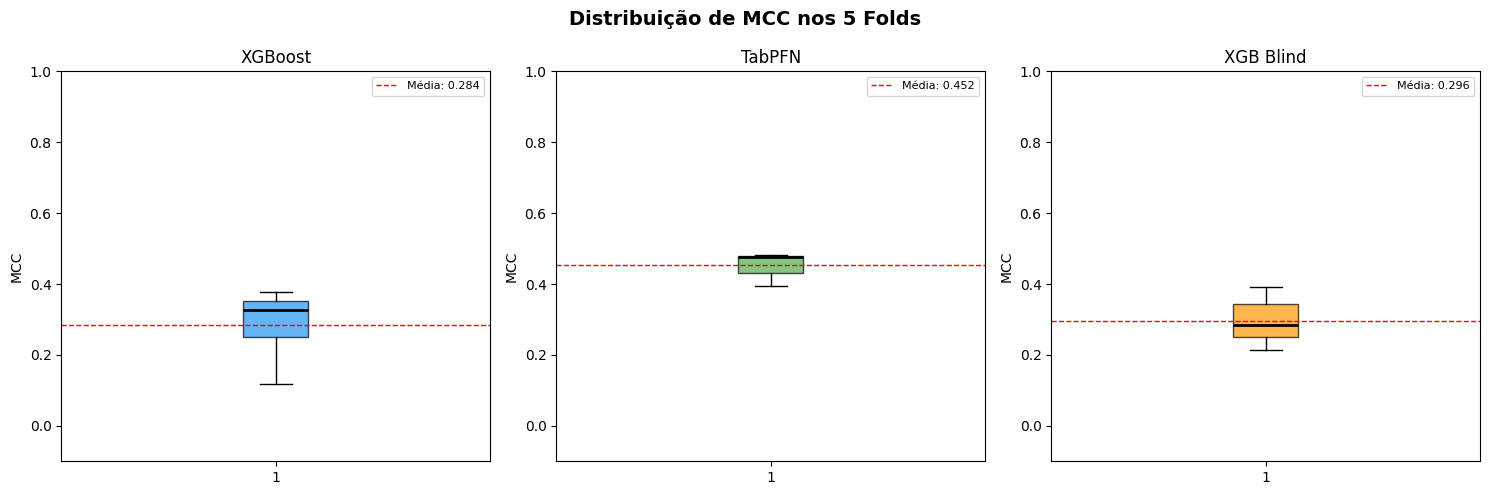

In [92]:
## 6.1 Boxplot de MCC por fold
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distribuição de MCC nos 5 Folds", fontsize=14, fontweight="bold")

model_data = [
    ("XGBoost",    results["xgboost"]["mcc"],  "#2196F3"),
    ("TabPFN",     results["tabpfn"]["mcc"],   "#4CAF50"),
    ("XGB Blind",  results["xgb_blind"]["mcc"],"#FF9800"),
]
for ax, (name, vals, color) in zip(axes, model_data):
    bp = ax.boxplot(vals, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color="black", linewidth=2))
    ax.set_title(name)
    ax.set_ylabel("MCC")
    ax.set_ylim(-0.1, 1.0)
    ax.axhline(np.mean(vals), color="red", linestyle="--", linewidth=1, label=f"Média: {np.mean(vals):.3f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("mcc_boxplot.png", dpi=150)
plt.show()

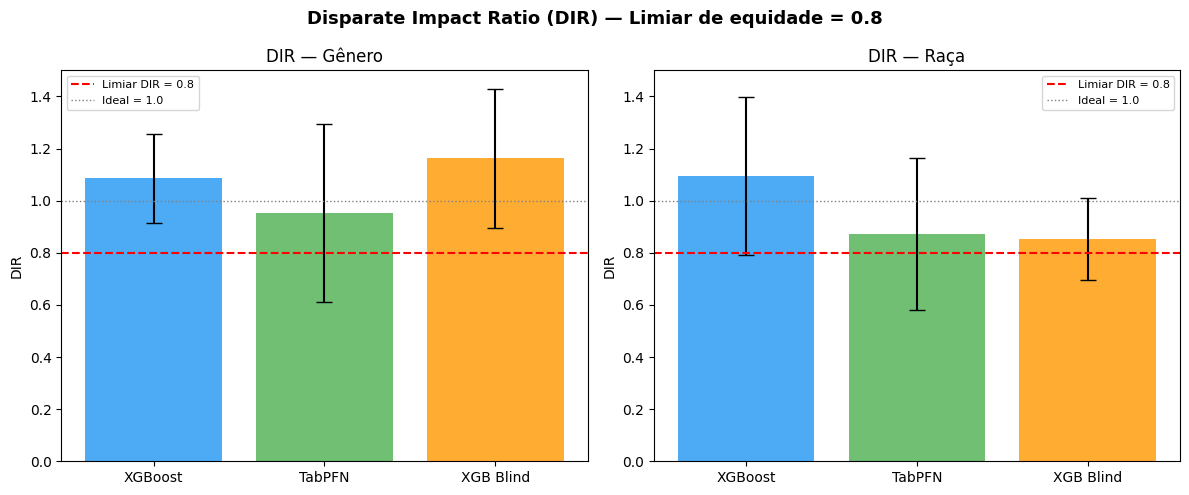

In [93]:
## 6.2 Gráfico de barras: DIR por atributo sensível
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Disparate Impact Ratio (DIR) — Limiar de equidade = 0.8", fontsize=13, fontweight="bold")

attrs = [("Gênero", "dir_gender"), ("Raça", "dir_race")]
models = ["xgboost", "tabpfn", "xgb_blind"]
labels = ["XGBoost", "TabPFN", "XGB Blind"]
colors = ["#2196F3", "#4CAF50", "#FF9800"]

for ax, (attr_name, key) in zip(axes, attrs):
    means = [np.nanmean(results[m][key]) for m in models]
    stds  = [np.nanstd(results[m][key]) for m in models]
    bars = ax.bar(labels, means, color=colors, alpha=0.8, yerr=stds, capsize=6)
    ax.axhline(0.8, color="red", linestyle="--", linewidth=1.5, label="Limiar DIR = 0.8")
    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1, label="Ideal = 1.0")
    ax.set_title(f"DIR — {attr_name}")
    ax.set_ylabel("DIR")
    ax.set_ylim(0, 1.5)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("dir_barplot.png", dpi=150)
plt.show()

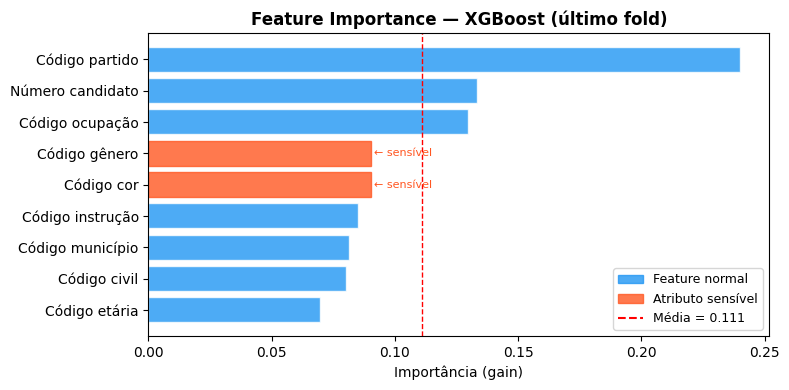

In [94]:
## 6.3 Feature Importance — XGBoost (último fold)
feat_imp = pd.DataFrame({
    "feature":    X.columns,
    "importance": last_models["xgboost"].feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(feat_imp) * 0.4)))
bars = ax.barh(feat_imp["feature"], feat_imp["importance"],
               color="#2196F3", alpha=0.8, edgecolor="white")
ax.set_title("Feature Importance — XGBoost (último fold)", fontweight="bold")
ax.set_xlabel("Importância (gain)")
ax.axvline(feat_imp["importance"].mean(), color="red", linestyle="--",
           linewidth=1)

# Destaca atributos sensíveis
for bar, feat in zip(bars, feat_imp["feature"]):
    if feat in (GENDER_COL, RACE_COL):
        bar.set_color("#FF5722")
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                "← sensível", va="center", fontsize=8, color="#FF5722")

blue_p = mpatches.Patch(color="#2196F3", alpha=0.8, label="Feature normal")
red_p  = mpatches.Patch(color="#FF5722", alpha=0.8, label="Atributo sensível")
mean_p = plt.Line2D([0], [0], color="red", linestyle="--",
                    label=f"Média = {feat_imp['importance'].mean():.3f}")
ax.legend(handles=[blue_p, red_p, mean_p], fontsize=9)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

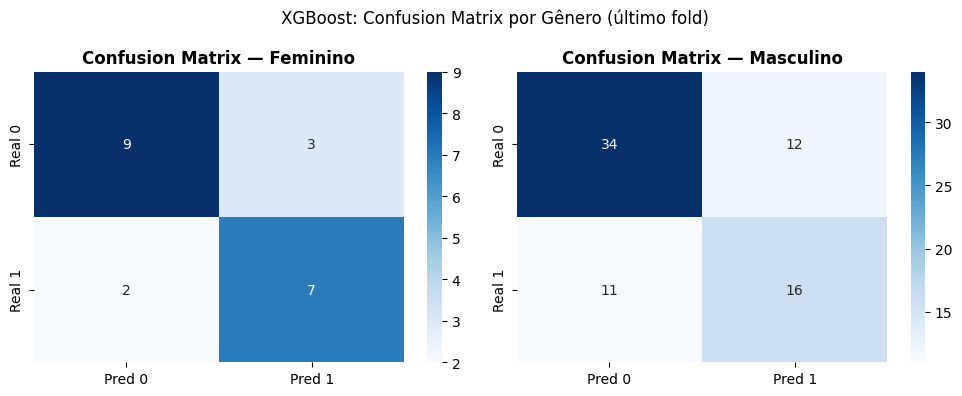

In [95]:
## 6.4 Heatmap de Confusion Matrix estratificada por gênero (último fold)
# Usa dados salvos durante o loop — sem necessidade de re-treino
y_last_te     = last_fold_data["y_test"]
y_pred_last   = last_fold_data["y_pred_xgb"]
sens_gen_last = last_fold_data["sens_gender"]

gender_labels = {v: k for k, v in gender_map.items()}
groups = sorted(np.unique(sens_gen_last))
fig, axes = plt.subplots(1, len(groups), figsize=(5 * len(groups), 4))
if len(groups) == 1:
    axes = [axes]

for ax, grp in zip(axes, groups):
    mask = sens_gen_last == grp
    if mask.sum() == 0:
        continue
    cm = confusion_matrix(y_last_te[mask], y_pred_last[mask], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["Real 0", "Real 1"])
    ax.set_title(f"Confusion Matrix — {gender_labels.get(grp, grp)}", fontweight="bold")

fig.suptitle("XGBoost: Confusion Matrix por Gênero (último fold)", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_by_gender.png", dpi=150)
plt.show()

# 7. Discussão

**Amplificação de Viés (XGBoost):** Se DIR < 0.8, o modelo amplifica a disparidade histórica entre grupos — candidatos do grupo não-privilegiado têm proporcionalmente menos predições positivas do que esperado. O uso de `scale_pos_weight` corrige o desbalanceamento de classes, tornando a comparação mais justa.

**Estabilidade (TabPFN):** Um desvio padrão menor do MCC entre os folds indica que a arquitetura transformer bayesiana é mais robusta em cenários de *small data* com desbalanceamento de classes. O TabPFN não requer ajuste de hiperparâmetros por fold, reduzindo variância.

**Equidade Nativa (TabPFN):** Se DIR (Gênero) e DIR (Raça) do TabPFN são mais próximos de 1.0 e EOD mais próximos de 0.0 do que o XGBoost, confirma-se a hipótese central: a inferência bayesiana mitiga viés sociodemográfico melhor que gradient boosting em datasets eleitorais de pequena escala.

**Experimento Blind:** ΔMCC quantifica o quanto a performance do XGBoost depende dos atributos protegidos (gênero e raça). Um ΔMCC pequeno (< 0.02) indica que o modelo não aprende diretamente via atributos sensíveis, mas pode fazê-lo via proxies (ex.: partido, ocupação). Um ΔMCC alto indica dependência direta.

**Análise de Pares Raciais (Interseccionalidade):** Calculamos DIR separadamente para Parda vs Branca e Preta vs Branca — o agregado "todos vs Branca" poderia mascarar disparidades específicas. Grupos com poucos representantes (ex.: Amarela, Indígena) produzem métricas instáveis, documentadas abaixo como limitação.

**Baseline Dummy:** O MCC do classificador ingênuo (stratified) contextualiza os resultados — qualquer MCC próximo ao baseline indica ausência de sinal preditivo real no modelo.

## 7.1. Limitações Declaradas

- **Tamanho amostral reduzido**: ~474 candidatos após filtro de segundo turno. Com n=5 folds, cada fold de teste tem ~95 amostras — insuficiente para testes de Wilcoxon com alta potência estatística.
- **Desbalanceamento extremo**: candidatos eleitos são minoria (~25% do dataset). `scale_pos_weight` mitiga, mas não elimina o efeito.
- **Instabilidade de DIR/EOD em grupos pequenos**: grupos raciais com < 5 representantes eleitos no subconjunto de teste produzem métricas não confiáveis (ex.: Amarela, Indígena). Reportados mas não interpretados como resultado definitivo.
- **Restrição do TabPFN**: desempenho ótimo em datasets com < 10k linhas por fold e < 100 features — compatível com este cenário, mas a restrição à CPU aumenta o tempo de execução.
- **Proxies de atributos sensíveis**: mesmo no XGBoost Blind, features como `Código partido` ou `Código ocupação` podem ser proxies de gênero ou raça, tornando a remoção de atributos sensíveis uma proteção incompleta.
- **Correção de Bonferroni conservadora**: com 5 testes e n=5 folds, a potência estatística é baixa. Em trabalho futuro, `RepeatedStratifiedKFold(n_repeats=3)` geraria 15 comparações pareadas, aumentando a confiabilidade do teste de Wilcoxon.

## 7.2. Trabalho Futuro

- **Repeated K-Fold (n_splits=5, n_repeats=3)** para 15 comparações pareadas no Wilcoxon.
- **SHAP values** para análise de contribuição individual e verificação de proxies.
- **Fairness pós-processamento** (ex.: calibração de threshold por grupo) para avaliar se é possível melhorar equidade sem perda expressiva de MCC.

# 8. Reprodutibilidade e Exportação

In [96]:
import xgboost as _xgb_mod, tabpfn as _pfn_mod, sklearn as _sk_mod, scipy as _scipy_mod

# --- CSV com resultados brutos de cada fold ---
all_metric_keys = list(results["xgboost"].keys())
rows = []
for model_name in ["xgboost", "tabpfn", "xgb_blind", "dummy"]:
    for fold_i in range(5):
        row = {"modelo": model_name, "fold": fold_i + 1}
        for metric in all_metric_keys:
            vals = results[model_name][metric]
            row[metric] = vals[fold_i] if fold_i < len(vals) else np.nan
        rows.append(row)
df_results = pd.DataFrame(rows)
df_results.to_csv("rigorous_benchmark_results.csv", index=False)
print("Exportado: rigorous_benchmark_results.csv")

# --- Feature importance CSV ---
# xgb_blind treina sem BLIND_DROP → importances têm tamanho diferente de X.columns
blind_features = [c for c in X.columns if c not in BLIND_DROP]
imp_xgb   = dict(zip(X.columns, last_models["xgboost"].feature_importances_))
imp_blind = dict(zip(blind_features, last_models["xgb_blind"].feature_importances_))

feat_imp_df = pd.DataFrame({
    "feature":              list(X.columns),
    "importance_xgboost":  [imp_xgb.get(c, np.nan) for c in X.columns],
    "importance_xgb_blind":[imp_blind.get(c, np.nan) for c in X.columns],  # NaN p/ cols removidas
    "is_sensitive":        [c in BLIND_DROP for c in X.columns],
}).sort_values("importance_xgboost", ascending=False)
feat_imp_df.to_csv("feature_fairness_benchmark_results.csv", index=False)
print("Exportado: feature_fairness_benchmark_results.csv")

# --- JSON com metadados do experimento ---
metadata = {
    "data_execucao": datetime.now().isoformat(),
    "random_state": RANDOM_STATE,
    "n_folds": 5,
    "n_amostras": int(len(df)),
    "n_features": int(X.shape[1]),
    "features": list(X.columns),
    "sensitive_features": BLIND_DROP,
    "versoes": {
        "xgboost":      _xgb_mod.__version__,
        "tabpfn":       _pfn_mod.__version__,
        "scikit-learn": _sk_mod.__version__,
        "scipy":        _scipy_mod.__version__,
        "pandas":       pd.__version__,
        "numpy":        np.__version__,
    },
    "grupos_privilegiados": {
        "genero": {"label": "Masculino", "codigo": int(PRIV_GENDER)},
        "raca":   {"label": "Branca",    "codigo": int(PRIV_RACE)},
    },
    "mapeamento_genero": {k: int(v) for k, v in gender_map.items()},
    "mapeamento_raca":   {k: int(v) for k, v in race_map.items()},
    "desbalanceamento": {
        "negativos": int((y == 0).sum()),
        "positivos": int((y == 1).sum()),
        "ratio": float((y == 0).sum() / (y == 1).sum()),
    },
    "resumo_metricas": {
        model: {
            "mcc_mean":        float(np.nanmean(results[model]["mcc"])),
            "mcc_std":         float(np.nanstd(results[model]["mcc"])),
            "dir_gender_mean": float(np.nanmean(results[model]["dir_gender"])),
            "eod_gender_mean": float(np.nanmean(results[model]["eod_gender"])),
        }
        for model in ["xgboost", "tabpfn", "xgb_blind", "dummy"]
    },
}
with open("experiment_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print("Exportado: experiment_metadata.json")

# --- Modelos treinados no último fold (.pkl) ---
with open("models_last_fold.pkl", "wb") as f:
    pickle.dump({
        "xgboost":   last_models["xgboost"],
        "tabpfn":    last_models["tabpfn"],
        "xgb_blind": last_models["xgb_blind"],
        "encoders":  encoders,
        "gender_map": gender_map,
        "race_map":   race_map,
    }, f)
print("Exportado: models_last_fold.pkl")
print("\nReproduza o experimento com RANDOM_STATE=42 e os mesmos arquivos de dados.")

Exportado: rigorous_benchmark_results.csv
Exportado: feature_fairness_benchmark_results.csv
Exportado: experiment_metadata.json
Exportado: models_last_fold.pkl

Reproduza o experimento com RANDOM_STATE=42 e os mesmos arquivos de dados.
